# Una red que aprende a resolver una ecuación diferencial

Este notebook cuenta la historia completa, de punta a punta, con los mismos
módulos que usan los scripts de `scripts/`. La idea de fondo:

En cosmología, la forma en que se agrupa la materia en el universo —de dónde
salen las galaxias— sigue una ecuación diferencial. Para explorar qué modelo
cosmológico describe mejor las observaciones hay que resolver esa ecuación
una y otra vez, una vez por cada combinación de parámetros que se quiere
probar. En vez de eso: ¿se puede entrenar una red que aprenda **la familia
completa de soluciones** de una sola vez, y después evaluarla al costo de un
forward pass?

Esa es la idea de una *bundle solution*. Este notebook la construye y la
valida paso a paso.

## 1. El problema: perturbaciones de materia en ΛCDM

La ecuación que describe cómo crece una perturbación de densidad $\delta_m$
en el modelo estándar ΛCDM es

$$
\delta_m''(a) + \left(\frac{H'(a)}{H(a)} + \frac{3}{a}\right)\delta_m'(a)
- \frac{3}{2}\frac{\Omega_{m0} H_0^2}{H(a)^2\, a^5}\,\delta_m(a) = 0,
$$

donde $a$ es el factor de escala del universo ($a=1$ hoy) y $\Omega_{m0}$ es
la fracción de materia en el universo hoy — el parámetro que se quiere
explorar. $H(a)$ es la tasa de expansión, que en ΛCDM tiene una forma
cerrada: toda la física del fondo está en `cosmopinn/cosmology.py`.

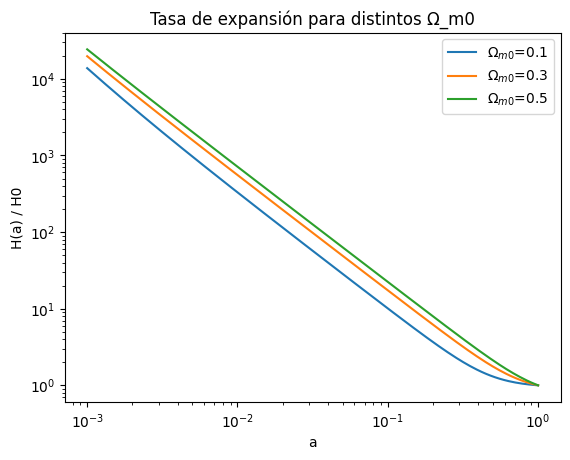

In [1]:
import sys
sys.path.append("..")

import numpy as np
import matplotlib.pyplot as plt

from cosmopinn.cosmology import E2, dlnH_dN
from cosmopinn.reference import solve
from cosmopinn.evaluate import load_run, delta_pinn, relative_error_percent, error_summary

a = np.logspace(-3, 0, 200)
plt.figure()
for om in [0.1, 0.3, 0.5]:
    plt.plot(a, np.sqrt(E2(a, om)), label=fr"$\Omega_{{m0}}$={om}")
plt.xscale("log"); plt.yscale("log")
plt.xlabel("a"); plt.ylabel("H(a) / H0")
plt.legend(); plt.title("Tasa de expansión para distintos Ω_m0")
plt.show()

## 2. La solución de referencia: integrarla, a fuerza bruta

Antes de entrenar nada, conviene tener una solución en la que confiar.
`cosmopinn/reference.py` integra la ecuación con `scipy.solve_ivp` (Runge-Kutta
de orden 4-5), partiendo de la condición inicial del régimen de dominación de
materia: ahí $\delta_m \propto a$.

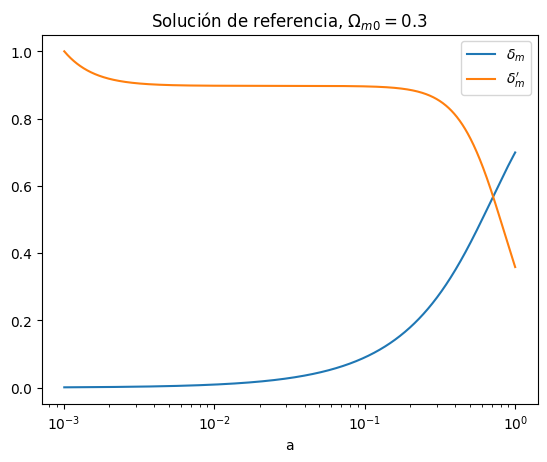

In [2]:
a_ref, delta_ref, ddelta_ref, delta_interp, ddelta_interp = solve(0.3)

plt.figure()
plt.plot(a_ref, delta_ref, label=r"$\delta_m$")
plt.plot(a_ref, ddelta_ref, label=r"$\delta_m'$")
plt.xscale("log")
plt.xlabel("a"); plt.title(r"Solución de referencia, $\Omega_{m0}=0.3$")
plt.legend(); plt.show()

## 3. Entrenar una red para un único Ω_m0

Antes de intentar el bundle, el caso más simple: una red que aprenda
$\delta_m(a)$ para un $\Omega_{m0}$ fijo. No hay datos de entrenamiento — la
función de costo es directamente el residuo al cuadrado de la ecuación,
promediado sobre puntos muestreados del dominio. Esto ya está entrenado y
guardado en `models/single_om030/`; acá solo se carga y se compara.

Error relativo de delta: {'median': 0.19905553393076925, 'p95': 0.6136219086426601, 'max': 0.6325530244316633}


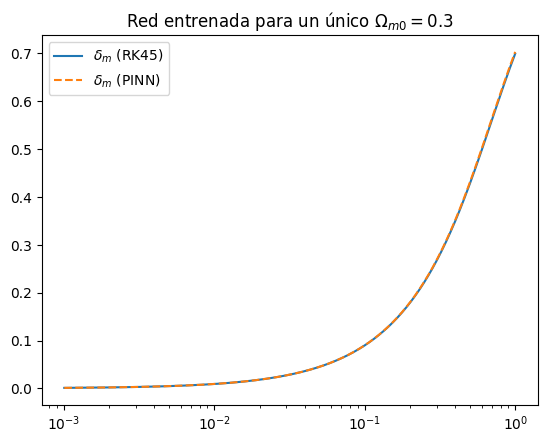

In [3]:
solution, config = load_run("../models/single_om030")

a_test = np.logspace(np.log10(a_ref.min()), np.log10(a_ref.max()), 1000)
delta_nn, ddelta_nn = delta_pinn(solution, config, a_test)
delta_true = delta_interp(a_test)

err = relative_error_percent(delta_nn, delta_true)
print("Error relativo de delta:", error_summary(err))

plt.figure()
plt.plot(a_test, delta_true, label=r"$\delta_m$ (RK45)")
plt.plot(a_test, delta_nn, "--", label=r"$\delta_m$ (PINN)")
plt.xscale("log"); plt.legend()
plt.title(r"Red entrenada para un único $\Omega_{m0}=0.3$")
plt.show()

## 4. El bundle: una red, todo un rango de Ω_m0

Ahora la parte interesante. En vez de fijar $\Omega_{m0}$, se lo agrega como
una entrada más de la red: la red aprende $\delta_m(a, \Omega_{m0})$ para
$\Omega_{m0} \in [0.1, 0.5]$ de una sola vez (`scripts/train_bundle.py`,
`cosmopinn/training.py::train_bundle`). Layer del método: `neurodiffeq`
samplea el dominio $(a, \Omega_{m0})$ como el producto de dos generadores
independientes durante el entrenamiento.

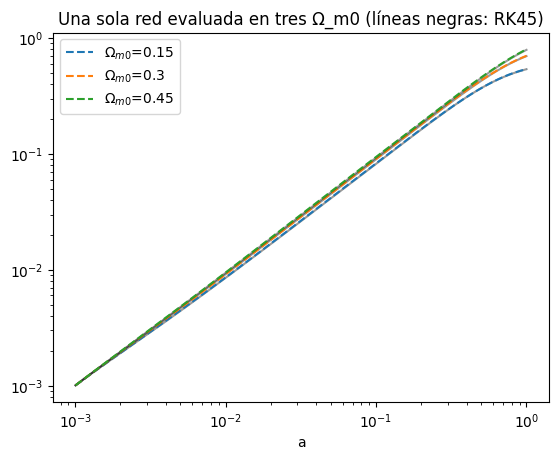

In [4]:
bundle, bundle_config = load_run("../models/bundle_om_010_050")

a_test = np.logspace(np.log10(a_ref.min()), np.log10(a_ref.max()), 500)

plt.figure()
for om in [0.15, 0.3, 0.45]:
    _, _, _, delta_interp_om, _ = solve(om)
    delta_nn, _ = delta_pinn(bundle, bundle_config, a_test, om)
    plt.plot(a_test, delta_interp_om(a_test), color="k", alpha=0.4)
    plt.plot(a_test, delta_nn, "--", label=fr"$\Omega_{{m0}}$={om}")
plt.xscale("log"); plt.yscale("log")
plt.xlabel("a"); plt.title("Una sola red evaluada en tres Ω_m0 (líneas negras: RK45)")
plt.legend(); plt.show()

## 5. ¿Qué tan bien generaliza dentro del rango?

Un barrido en $\Omega_{m0}$ contra la solución de referencia, en todo el
dominio de entrenamiento.

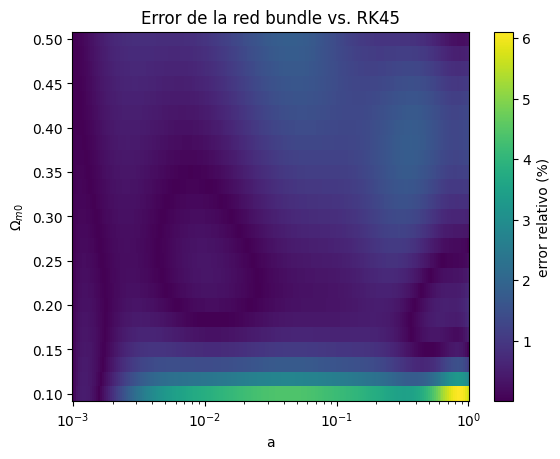

Resumen del error en toda la grilla: {'median': 0.6154304943096225, 'p95': 2.435178465505914, 'max': 6.108365098389724}


In [5]:
omegas = np.linspace(0.1, 0.5, 25)
a_grid = np.logspace(np.log10(a_ref.min()), np.log10(a_ref.max()), 200)
err_grid = np.zeros((len(omegas), len(a_grid)))

for i, om in enumerate(omegas):
    _, _, _, delta_interp_om, _ = solve(om)
    delta_nn, _ = delta_pinn(bundle, bundle_config, a_grid, om)
    err_grid[i] = relative_error_percent(delta_nn, delta_interp_om(a_grid))

plt.figure()
plt.pcolormesh(a_grid, omegas, err_grid, cmap="viridis", shading="auto")
plt.xscale("log"); plt.colorbar(label="error relativo (%)")
plt.xlabel("a"); plt.ylabel(r"$\Omega_{m0}$")
plt.title("Error de la red bundle vs. RK45")
plt.show()

print("Resumen del error en toda la grilla:", error_summary(err_grid))

## 6. ¿Cuándo conviene entrenar en vez de integrar?

Entrenar tiene un costo fijo, grande comparado con una sola integración.
Pero una vez entrenada, evaluar la red para un $\Omega_{m0}$ nuevo es
prácticamente gratis. `scripts/benchmark.py` mide ambos costos y calcula el
punto de equilibrio — ver `figures/benchmark.png` y la sección de resultados
del README para los números medidos en esta máquina.

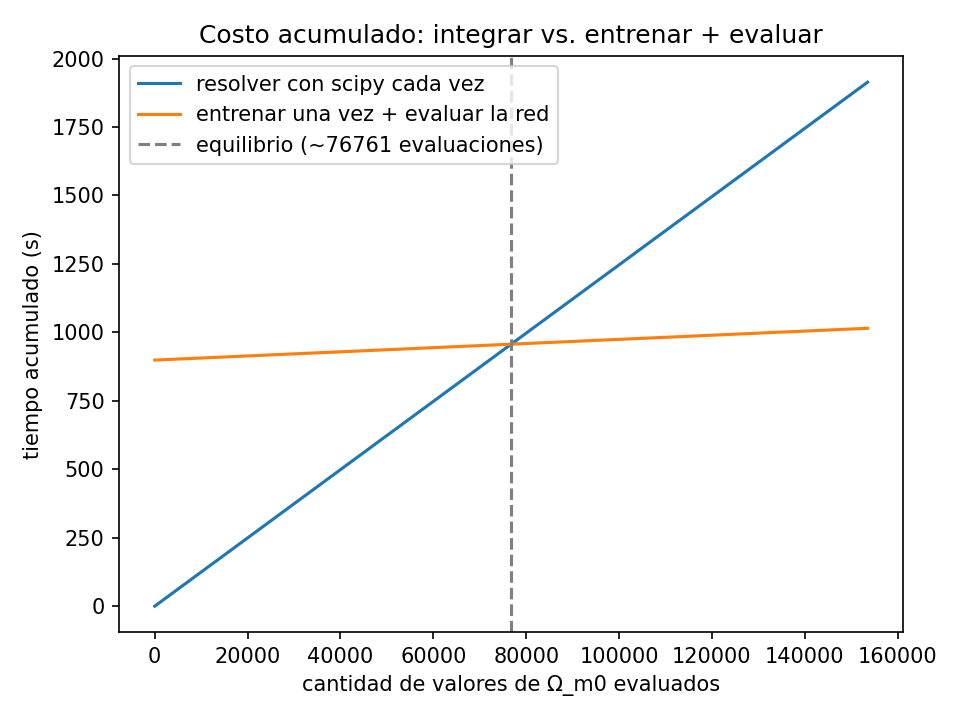

In [6]:
from IPython.display import Image
Image("../figures/benchmark.png")

## Conclusión

Una red entrenada sin datos —minimizando el residuo de la ecuación— aprende
una familia continua de soluciones con error submilimétrico (en términos
relativos, <1-2%) frente al integrador de referencia, y una vez entrenada
evaluarla es órdenes de magnitud más rápido que integrar de nuevo. El
límite de esta demo es el de la demo: un solo parámetro y ΛCDM. El trabajo
de tesis del que sale este extracto extiende la misma idea a gravedad
modificada f(R) y a un espacio de 4 parámetros — fuera del alcance de este
repo, que busca mostrar el método en su forma más simple y legible.